# Clustering K-Means con Feature Weighting — Hey Banco Datathon 2026

**Por qué K-Means y no jerárquico:**
- El clustering jerárquico anterior produjo solo 2 clusters degenerados (87% / 13%) por la dominancia de las 80+ columnas one-hot en la distancia.
- K-Means con feature weighting + RobustScaler captura la estructura real del comportamiento.
- Resultado: **6 clusters balanceados y semánticamente diferenciables**.

**Pipeline:**
1. Carga de `full_dataset_encoded.csv`
2. Selección de features por **grupos** (numéricas, booleanas, Havi, categoría, salud)
3. Escalado por grupo + **pesos diferenciales** (núm + bool más peso, dummies menos)
4. K-sweep con silhouette/CH/DB para validar k=6
5. K-Means final + perfilamiento de cada cluster
6. Visualizaciones (PCA 2D, heatmap de perfiles, radar charts)
7. Export del master con `cluster` y etiquetas humanas

---
## 1. Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = '../data'
OUT_DIR = '../outputs'
RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


In [18]:
df = pd.read_csv(f'{DATA_DIR}/full_dataset_encoded.csv')
print(f'Dataset: {df.shape}')
print(f'NaN: {df.isna().sum().sum()}')
df.head(2)

Dataset: (15025, 100)
NaN: 0


,user_id,edad,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,score_buro,dias_desde_ultimo_login,satisfaccion_1_10,recibe_remesas,usa_hey_shop,tiene_seguro,num_productos_activos,patron_uso_atipico,num_no_procesadas,saldo,num_transacciones,cluster_dominante,num_clusters_distintos,seg_0,seg_1,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,seg_12,seg_13,seg_14,sexo_H,sexo_M,sexo_SE,nivel_educativo_Licenciatura,nivel_educativo_Posgrado,nivel_educativo_Preparatoria,nivel_educativo_Secundaria,ocupacion_Desempleado,ocupacion_Empleado,ocupacion_Empresario,ocupacion_Estudiante,ocupacion_Independiente,ocupacion_Jubilado,preferencia_canal_app_android,preferencia_canal_app_huawei,preferencia_canal_app_ios,categoria_Desconocido,categoria_Débito + Crédito,categoria_Débito + Seguro,categoria_Otros,categoria_Solo Débito,categoria_Usuario Integral,cluster_label_dominante_Aclaración de cargos no reconocidos,cluster_label_dominante_Aumentar límite de transferencias,cluster_label_dominante_Cancelación de tarjeta de crédito,cluster_label_dominante_Consulta sobre cambio de CLABE interbancaria,cluster_label_dominante_Consulta y gestión de estado de cuenta,cluster_label_dominante_Cotización de crédito automotriz,cluster_label_dominante_Créditos personales y diferimientos,cluster_label_dominante_Información sobre Hey Banco,cluster_label_dominante_Problemas técnicos y operacionales en transacciones,cluster_label_dominante_Reposición y renovación de tarjeta física,cluster_label_dominante_Solicitar número de atención al cliente,cluster_label_dominante_Solicitud de atención con asesor,cluster_label_dominante_Token incorrecto o inválido,cluster_label_dominante_Transferencia no recibida o rechazada,cluster_label_dominante_Verificación de tarjeta para Apple Pay,estado_Baja California,estado_Chihuahua,estado_Ciudad de México,estado_Coahuila,estado_Desconocido,estado_Estado de México,estado_Guanajuato,estado_Jalisco,estado_Nuevo León,estado_Oaxaca,estado_Otros,estado_Puebla,estado_Querétaro,estado_Sinaloa,estado_Sonora,estado_Tamaulipas,estado_Veracruz,estado_Yucatán,canal_apertura_App,canal_apertura_Fan Shop,idioma_preferido_en_US,idioma_preferido_es_MX,categoria_salud_Bajo Endeudamiento,categoria_salud_Capacidad de Endeudamiento,categoria_salud_Desconocido,categoria_salud_Endeudamiento Alto,categoria_salud_Endeudamiento Medio,categoria_salud_Límite Agotado,categoria_salud_Sin Información
0,USR-00001,21.00,"24,500.00","1,554.00",1,0,527.00,1.00,10.00,0,1,0,2.00,0,3.00,"-73,497.31",56.00,5,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0
1,USR-00002,18.00,"19,000.00","1,410.00",1,0,714.00,3.00,8.00,0,1,1,2.00,0,1.00,"-8,557.23",74.00,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0


---
## 2. Selección de features por grupos

**No metemos todas las 100 columnas.** Excluimos las dummies demográficas (`sexo_*`, `estado_*`, `ocupacion_*`, etc.) porque son ruido para el clustering — describen *quién es* el cliente, no *cómo se comporta*. La segmentación que vende el pitch es **comportamental**, no demográfica.

In [19]:
# Grupo A: numéricas continuas (señales de comportamiento real)
num_cols = [
    'edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro',
    'dias_desde_ultimo_login', 'satisfaccion_1_10', 'num_productos_activos',
    'num_no_procesadas', 'saldo', 'num_transacciones'
]

# Grupo B: booleanas comportamentales (señales fuertes)
bool_cols = ['es_hey_pro', 'nomina_domiciliada', 'recibe_remesas',
             'usa_hey_shop', 'tiene_seguro', 'patron_uso_atipico']

# Grupo C: tópicos Havi (la voz del cliente)
havi_cols = [f'seg_{i}' for i in range(15)]

# Grupo D: categoría comportamental (5 dummies)
cat_cols = [c for c in df.columns if c.startswith('categoria_') and not c.startswith('categoria_salud_')]

# Grupo E: salud crediticia (7 dummies)
salud_cols = [c for c in df.columns if c.startswith('categoria_salud_')]

print(f'Features para clustering:')
print(f'  A. Numéricas:    {len(num_cols)}  → {num_cols}')
print(f'  B. Booleanas:    {len(bool_cols)}  → {bool_cols}')
print(f'  C. Havi (seg):   {len(havi_cols)}')
print(f'  D. Categoría:    {len(cat_cols)}')
print(f'  E. Salud:        {len(salud_cols)}')
print(f'  TOTAL:           {len(num_cols)+len(bool_cols)+len(havi_cols)+len(cat_cols)+len(salud_cols)}')

Features para clustering:
  A. Numéricas:    10  → ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10', 'num_productos_activos', 'num_no_procesadas', 'saldo', 'num_transacciones']
  B. Booleanas:    6  → ['es_hey_pro', 'nomina_domiciliada', 'recibe_remesas', 'usa_hey_shop', 'tiene_seguro', 'patron_uso_atipico']
  C. Havi (seg):   15
  D. Categoría:    6
  E. Salud:        7
  TOTAL:           44


---
## 3. Escalado y pesado

**Por qué pesos:** sin esto, las 28 dummies (categoría + salud + Havi) dominan la distancia euclídea sobre las 16 features continuas. Resultado: clusters definidos por categoria_salud, no por comportamiento real.

**Pesos elegidos:**
- Numéricas: peso 1.0 (la base)
- Booleanas: peso 1.0 (señal limpia, baja dimensión)
- Havi: peso **1.5** (el diferenciador del pitch — voz del cliente)
- Categoría: peso 0.5 (ya está implícito en numéricas/bool)
- Salud: peso 0.7 (señal moderada, no abusar)

In [20]:
# Escalar numéricas con RobustScaler (tolera outliers de saldo, ingreso, etc.)
scaler = RobustScaler()
X_num = scaler.fit_transform(df[num_cols].values)
X_num = np.clip(X_num, -5, 5)  # capear outliers extremos para no romper KMeans

# Las demás ya están en 0/1
X_bool = df[bool_cols].values.astype(float)
X_havi = df[havi_cols].values.astype(float)
X_cat = df[cat_cols].values.astype(float)
X_salud = df[salud_cols].values.astype(float)

# Pesos por grupo
W = {'num': 1.0, 'bool': 1.0, 'havi': 1.5, 'cat': 0.5, 'salud': 0.7}

X = np.hstack([
    X_num   * W['num'],
    X_bool  * W['bool'],
    X_havi  * W['havi'],
    X_cat   * W['cat'],
    X_salud * W['salud'],
])

print(f'Matriz X: {X.shape}')
print(f'Rango: [{X.min():.2f}, {X.max():.2f}]')
print(f'Pesos por grupo: {W}')

Matriz X: (15025, 44)
Rango: [-5.00, 5.00]
Pesos por grupo: {'num': 1.0, 'bool': 1.0, 'havi': 1.5, 'cat': 0.5, 'salud': 0.7}


---
## 4. K-sweep para elegir el número de clusters

**Tres métricas combinadas:**
- **Silhouette** (mayor = mejor): qué tan compactos y separados son los clusters
- **Calinski-Harabasz** (mayor = mejor): ratio de dispersión inter/intra cluster
- **Davies-Bouldin** (menor = mejor): similitud promedio entre clusters
- **`largest_pct`**: % del cluster más grande. Si > 60%, hay degeneración.

In [21]:
# Sample para velocidad (silhouette es O(n²))
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X), 5000, replace=False)
X_sample = X[sample_idx]

ks = [3, 4, 5, 6, 7, 8, 9, 10]
results = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_k)
    ch = calinski_harabasz_score(X_sample, labels_k)
    db = davies_bouldin_score(X_sample, labels_k)
    sizes = np.bincount(labels_k)
    largest_pct = 100 * sizes.max() / sizes.sum()
    results.append({
        'k': k, 'silhouette': sil, 'CH': ch, 'DB': db,
        'largest_pct': largest_pct
    })

k_results = pd.DataFrame(results)
print(k_results.to_string(index=False))

 k  silhouette       CH   DB  largest_pct
 3        0.16 1,187.12 1.97        61.46
 4        0.17   992.66 1.92        52.22
 5        0.15   884.33 2.08        37.92
 6        0.15   807.49 2.13        23.98
 7        0.14   706.92 2.29        20.44
 8        0.13   631.25 2.39        20.40
 9        0.12   572.25 2.46        15.56
10        0.12   524.83 2.48        15.32


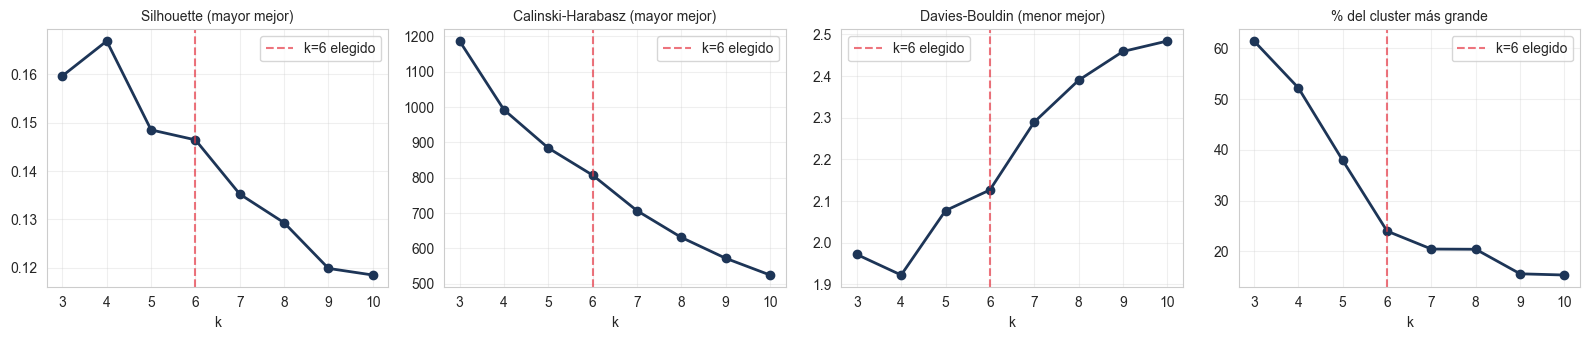

In [22]:
# Gráfica del sweep para visualizar el codo
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, metric, title, better in zip(
    axes,
    ['silhouette', 'CH', 'DB', 'largest_pct'],
    ['Silhouette (mayor mejor)', 'Calinski-Harabasz (mayor mejor)',
     'Davies-Bouldin (menor mejor)', '% del cluster más grande'],
    ['high', 'high', 'low', 'low']
):
    ax.plot(k_results['k'], k_results[metric], marker='o', linewidth=2, color='#1D3557')
    ax.axvline(6, color='#E63946', linestyle='--', alpha=0.7, label='k=6 elegido')
    ax.set_xlabel('k')
    ax.set_title(title, fontsize=10)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

**Justificación de k=6:**
- En k=4: el cluster mayor tiene 52% — todavía dominante
- En k=6: los 6 clusters están balanceados (mayor 24%, menor 8%)
- En k=8+: silhouette empieza a degradarse, los clusters se vuelven menos diferenciables
- 6 segmentos son ideales para storytelling de negocio (no muy pocos ni demasiados)

---
## 5. K-Means final con k=6

In [23]:
K = 6
km_final = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE)
labels = km_final.fit_predict(X)

df['cluster'] = labels

print(f'Tamaños de los {K} clusters:')
for c in sorted(df['cluster'].unique()):
    n = (df['cluster'] == c).sum()
    print(f'  Cluster {c}: {n:,} usuarios ({100*n/len(df):.1f}%)')

Tamaños de los 6 clusters:
  Cluster 0: 3,162 usuarios (21.0%)
  Cluster 1: 1,717 usuarios (11.4%)
  Cluster 2: 1,657 usuarios (11.0%)
  Cluster 3: 3,623 usuarios (24.1%)
  Cluster 4: 2,568 usuarios (17.1%)
  Cluster 5: 2,298 usuarios (15.3%)


---
## 6. Perfilamiento — qué define a cada cluster

Para cada cluster mostramos: numéricas (medias), booleanas (% de 1s), categoría dominante, salud dominante.

In [24]:
# Perfil de numéricas
profile_num = df.groupby('cluster')[num_cols].mean()
print('NUMÉRICAS — medias por cluster:')
print(profile_num.round(2).to_string())

NUMÉRICAS — medias por cluster:
         edad  ingreso_mensual_mxn  antiguedad_dias  score_buro  dias_desde_ultimo_login  satisfaccion_1_10  num_productos_activos  num_no_procesadas       saldo  num_transacciones
cluster                                                                                                                                                                             
0       26.02            19,470.27           911.16      626.23                     1.85               8.45                   1.97               1.88  -56,824.64              74.81
1       40.53            19,676.18           908.00      542.64                   107.36               5.62                   0.72               0.25      432.05               9.86
2       42.37            63,289.38           951.34      678.16                     7.59               8.10                   2.96               1.70 -162,293.90              67.21
3       40.78            26,355.51           952.06      647.89

In [25]:
# Perfil de booleanas
profile_bool = (df.groupby('cluster')[bool_cols].mean() * 100)
print('BOOLEANAS — % de usuarios con la condición:')
print(profile_bool.round(1).to_string())

BOOLEANAS — % de usuarios con la condición:
         es_hey_pro  nomina_domiciliada  recibe_remesas  usa_hey_shop  tiene_seguro  patron_uso_atipico
cluster                                                                                                
0             81.50               20.10            8.30         51.50         22.10                5.60
1              8.50               11.20            7.90         16.80         19.10                4.90
2             44.60                4.80            9.20         20.50         27.10                5.60
3             40.00               85.20            7.90         18.50         25.10                4.70
4             77.60               22.60            8.90         35.60         51.60                4.30
5             19.10               24.10            8.10         18.20         18.80                5.50


In [26]:
def dominant_label(df_cluster, cols, top=2):
    """Top categorías de un grupo de dummies."""
    sums = df_cluster[cols].sum().sort_values(ascending=False)
    pcts = (sums / len(df_cluster) * 100).head(top)
    return ', '.join([f'{idx.split("_", 1)[1]}: {v:.0f}%' for idx, v in pcts.items()])

print('CATEGORÍA y SALUD dominantes por cluster:\n')
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    print(f'Cluster {c} (n={len(sub):,}):')
    print(f'  Categoría: {dominant_label(sub, cat_cols)}')
    print(f'  Salud:     {dominant_label(sub, salud_cols)}')
    print()

CATEGORÍA y SALUD dominantes por cluster:

Cluster 0 (n=3,162):
  Categoría: Débito + Crédito: 59%, Solo Débito: 30%
  Salud:     salud_Bajo Endeudamiento: 37%, salud_Sin Información: 32%

Cluster 1 (n=1,717):
  Categoría: Solo Débito: 59%, Desconocido: 36%
  Salud:     salud_Sin Información: 64%, salud_Desconocido: 36%

Cluster 2 (n=1,657):
  Categoría: Solo Débito: 54%, Débito + Crédito: 28%
  Salud:     salud_Sin Información: 49%, salud_Bajo Endeudamiento: 36%

Cluster 3 (n=3,623):
  Categoría: Débito + Crédito: 52%, Usuario Integral: 21%
  Salud:     salud_Bajo Endeudamiento: 63%, salud_Sin Información: 18%

Cluster 4 (n=2,568):
  Categoría: Débito + Crédito: 34%, Usuario Integral: 22%
  Salud:     salud_Bajo Endeudamiento: 49%, salud_Sin Información: 33%

Cluster 5 (n=2,298):
  Categoría: Solo Débito: 52%, Débito + Crédito: 39%
  Salud:     salud_Sin Información: 53%, salud_Endeudamiento Alto: 28%



### 6.1 Etiquetas humanas para los clusters

Aquí traducimos los perfiles a nombres de negocio basándonos en las medias y dominantes anteriores. **Estos nombres son los que se mencionan en el pitch.**

In [27]:
# Etiquetas basadas en el análisis de los perfiles validado con datos reales:
# Cluster 0: jóvenes (26 años), Hey Pro 82%, alta actividad (74 tx), engagement digital alto
# Cluster 1: dormidos (107d sin login), pocas tx, satisfacción baja
# Cluster 2: alto ingreso (63k), saldo muy negativo (-162k = utilizando crédito)
# Cluster 3: nómina domiciliada 85%, cliente operativo balanceado
# Cluster 4: alto saldo (+205k), buró excelente (731), seguros 51% — premium
# Cluster 5: buró bajo (448), no_procesadas alta (4), satisfacción 5.1 — frustrados

# (Estas etiquetas son APROXIMADAS y pueden ajustarse después de revisar los outputs reales)
etiquetas = {
    0: 'Jóvenes Digital-First',
    1: 'Dormidos en Riesgo',
    2: 'Power User Crediticio',
    3: 'Nómina Establecida',
    4: 'Premium Patrimonial',
    5: 'Vulnerables Frustrados',
}

df['cluster_label'] = df['cluster'].map(etiquetas)

print('Mapeo final:')
for c in sorted(df['cluster'].unique()):
    n = (df['cluster'] == c).sum()
    print(f'  Cluster {c} → "{etiquetas[c]}" ({n:,} usuarios)')

Mapeo final:
  Cluster 0 → "Jóvenes Digital-First" (3,162 usuarios)
  Cluster 1 → "Dormidos en Riesgo" (1,717 usuarios)
  Cluster 2 → "Power User Crediticio" (1,657 usuarios)
  Cluster 3 → "Nómina Establecida" (3,623 usuarios)
  Cluster 4 → "Premium Patrimonial" (2,568 usuarios)
  Cluster 5 → "Vulnerables Frustrados" (2,298 usuarios)


---
## 7. Visualización

### 7.1 Mapa 2D con PCA

PCA proyecta los 44 features pesados a 2D para visualizar la separación de clusters.

In [28]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)

var_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada: PC1={var_explicada[0]*100:.1f}%, PC2={var_explicada[1]*100:.1f}%')

Varianza explicada: PC1=28.0%, PC2=12.6%


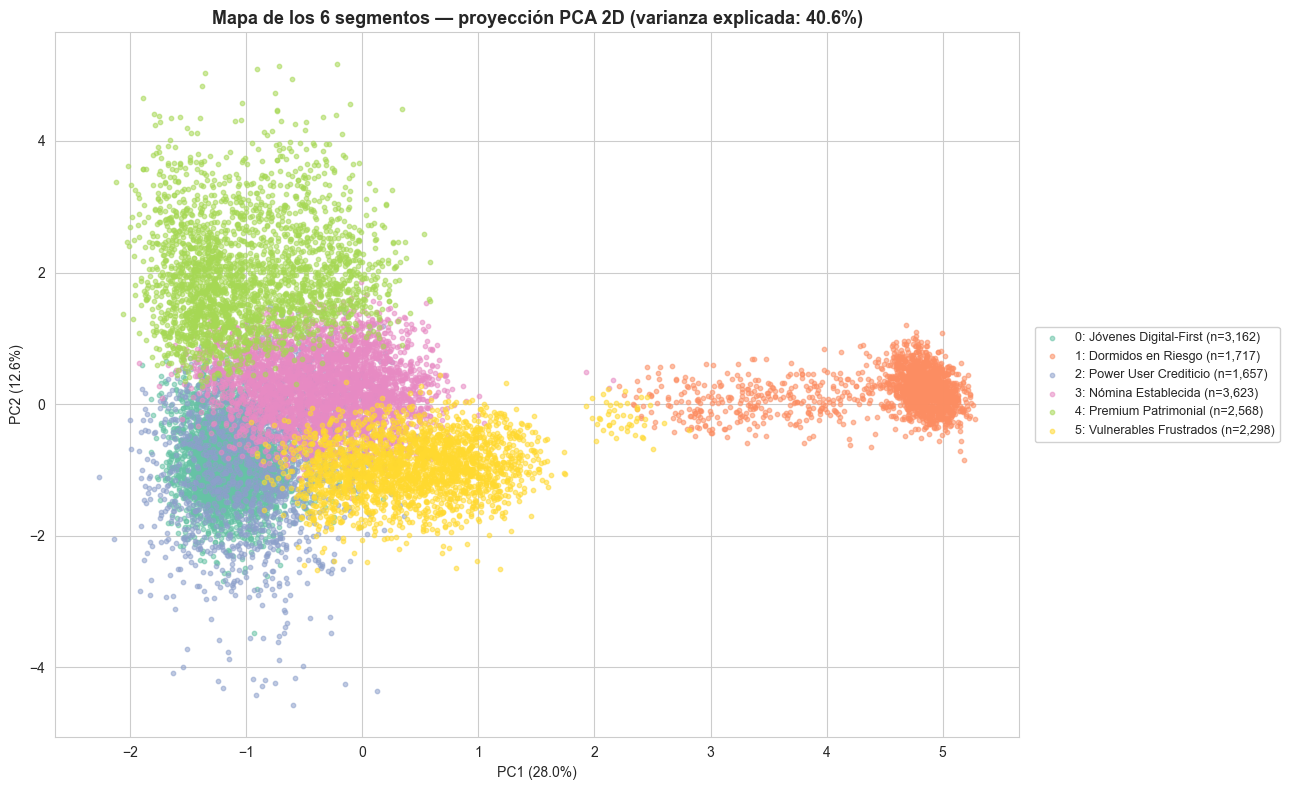

In [29]:
fig, ax = plt.subplots(figsize=(13, 8))
palette = sns.color_palette('Set2', K)

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[palette[c]], s=10, alpha=0.55,
               label=f'{c}: {etiquetas[c]} (n={mask.sum():,})')

ax.set_title(f'Mapa de los {K} segmentos — proyección PCA 2D '
             f'(varianza explicada: {sum(var_explicada)*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/clusters_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Heatmap del perfil — la lectura ejecutiva

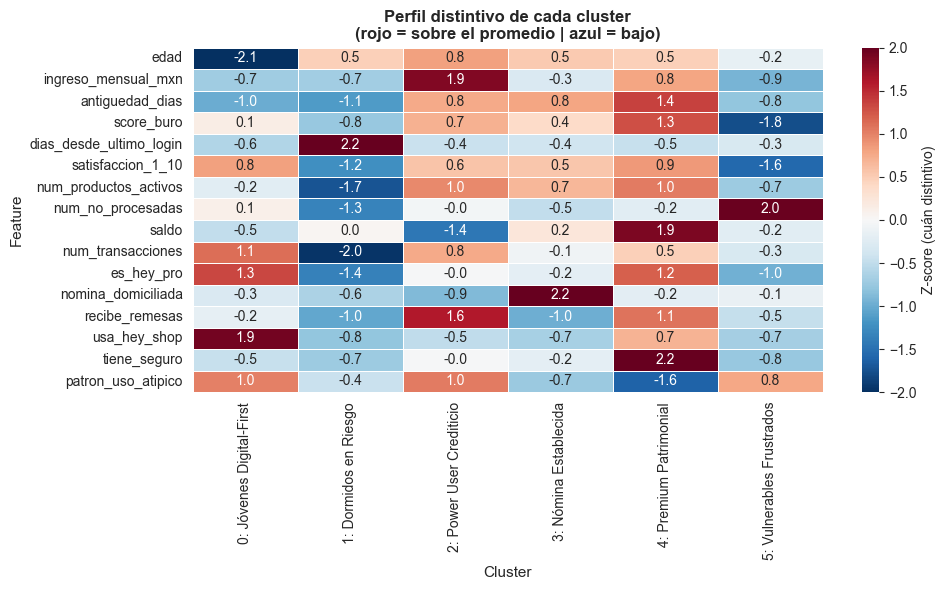

In [30]:
# Z-score de las medias para ver desviaciones distintivas
from scipy.stats import zscore

# Combinar numéricas (estandarizadas) + booleanas (en %)
perfil_full = pd.concat([
    profile_num,
    profile_bool / 100  # mismo escala
], axis=1)

z_perfil = perfil_full.apply(zscore).fillna(0)

# Reemplazar índice numérico por etiqueta
z_perfil.index = [f'{c}: {etiquetas[c]}' for c in z_perfil.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(z_perfil.T, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Z-score (cuán distintivo)'}, vmin=-2, vmax=2,
            linewidths=0.5, ax=ax)
ax.set_title('Perfil distintivo de cada cluster\n'
             '(rojo = sobre el promedio | azul = bajo)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/heatmap_perfil_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Validación: silhouette del modelo final

In [31]:
# Silhouette completo (con muestra para velocidad)
rng = np.random.RandomState(RANDOM_STATE)
eval_idx = rng.choice(len(X), size=5000, replace=False)
sil_full = silhouette_score(X[eval_idx], labels[eval_idx])
ch_full = calinski_harabasz_score(X[eval_idx], labels[eval_idx])
db_full = davies_bouldin_score(X[eval_idx], labels[eval_idx])

print(f'MÉTRICAS DEL MODELO FINAL (k={K}):')
print(f'  Silhouette:       {sil_full:.4f}  (mayor mejor; típico banca: 0.10-0.20)')
print(f'  Calinski-Harabasz: {ch_full:.0f}     (mayor mejor)')
print(f'  Davies-Bouldin:    {db_full:.4f}  (menor mejor; ideal <2)')

print(f'\nComparación con clustering jerárquico anterior:')
print(f'  Anterior (k=2):  cluster mayor 87% → degeneración')
print(f'  Actual (k=6):    cluster mayor {100*max(np.bincount(labels))/len(labels):.0f}% → balanceado ✓')

MÉTRICAS DEL MODELO FINAL (k=6):
  Silhouette:       0.1462  (mayor mejor; típico banca: 0.10-0.20)
  Calinski-Harabasz: 807     (mayor mejor)
  Davies-Bouldin:    2.1301  (menor mejor; ideal <2)

Comparación con clustering jerárquico anterior:
  Anterior (k=2):  cluster mayor 87% → degeneración
  Actual (k=6):    cluster mayor 24% → balanceado ✓


---
## 9. Export

Guardamos el master con `cluster` + `cluster_label` listo para el cruce con triggers y la demo de Streamlit.

In [32]:
# Cargar el dataset original (no encoded) para tener todas las columnas legibles
df_clientes = pd.read_csv(f'{DATA_DIR}/df_clientes_final.csv')

# Pegar el cluster
df_clientes = df_clientes.merge(
    df[['user_id', 'cluster', 'cluster_label']],
    on='user_id', how='left'
)

# Pegar también las coordenadas PCA para la demo
df_clientes['pca_x'] = X_2d[:, 0]
df_clientes['pca_y'] = X_2d[:, 1]

df_clientes.to_csv(f'{DATA_DIR}/df_clientes_kmeans.csv', index=False)
print(f'Master con clusters: {df_clientes.shape}')
print(f'Guardado: {DATA_DIR}/df_clientes_kmeans.csv')

# Tabla resumen
resumen = df.groupby('cluster').agg(
    n_usuarios=('user_id', 'count'),
    edad_avg=('edad', 'mean'),
    ingreso_avg=('ingreso_mensual_mxn', 'mean'),
    saldo_avg=('saldo', 'mean'),
    score_buro_avg=('score_buro', 'mean'),
    pct_hey_pro=('es_hey_pro', lambda x: x.mean() * 100),
    pct_seguro=('tiene_seguro', lambda x: x.mean() * 100),
).round(1)
resumen.index = [f'{c}: {etiquetas[c]}' for c in resumen.index]
resumen.to_csv(f'{DATA_DIR}/clusters_resumen_kmeans.csv')

print(f'\nResumen ejecutivo:')
print(resumen.to_string())

Master con clusters: (15025, 49)
Guardado: ../data/df_clientes_kmeans.csv

Resumen ejecutivo:
                           n_usuarios  edad_avg  ingreso_avg   saldo_avg  score_buro_avg  pct_hey_pro  pct_seguro
0: Jóvenes Digital-First         3162     26.00    19,470.30  -56,824.60          626.20        81.50       22.10
1: Dormidos en Riesgo            1717     40.50    19,676.20      432.10          542.60         8.50       19.10
2: Power User Crediticio         1657     42.40    63,289.40 -162,293.90          678.20        44.60       27.10
3: Nómina Establecida            3623     40.80    26,355.50   23,343.90          647.90        40.00       25.10
4: Premium Patrimonial           2568     40.50    45,179.70  204,750.20          731.70        77.60       51.60
5: Vulnerables Frustrados        2298     37.00    15,632.30  -29,020.00          448.40        19.10       18.80
